
<h1 style="
  display:inline-block;
  font-family: 'Inter', Roboto, Arial, sans-serif;
  font-weight:700;
  font-size:5rem;
  background: linear-gradient(90deg, #007bff, #6f42c1);
  -webkit-background-clip: text;
  -webkit-text-fill-color: transparent;
  margin-bottom: 0.5rem;
">News Category Classification</h1>


### Objective

The goal of this project is **classify news articles into their respective categories** based on their textual content. The model processes and cleans the text, converts it into numerical features, and predicts the category of each news article accurately.


---

In [39]:
import os
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import warnings
warnings.filterwarnings("ignore")
# nltk resources
nltk.download('stopwords')
nltk.download('wordnet')


DATA_DIR = "raw data"
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)


[nltk_data] Downloading package stopwords to C:\Users\ALL IN
[nltk_data]     ONE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ALL IN
[nltk_data]     ONE\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [40]:
# Load Data
train_path = os.path.join(DATA_DIR, "train.csv")
test_path  = os.path.join(DATA_DIR, "test.csv")

train_df = pd.read_csv(train_path, header=0, names=['class_index','title','description'])
test_df  = pd.read_csv(test_path,  header=0, names=['class_index','title','description'])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head(5)


Train shape: (120000, 3)
Test shape: (7600, 3)


,class_index,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [41]:
train_df['class_index'] = train_df['class_index'].astype(int)
test_df['class_index']  = test_df['class_index'].astype(int)

In [42]:
print(train_df['class_index'].unique())
print(test_df['class_index'].unique())

[3 4 2 1]
[3 4 2 1]


In [43]:
train_df['text'] = train_df['title'].fillna('') + ". " + train_df['description'].fillna('')
test_df['text']  = test_df['title'].fillna('') + ". " + test_df['description'].fillna('')

label_map = {1:"World", 2:"Sports", 3:"Business", 4:"Sci/Tech"}
train_df['label'] = train_df['class_index'].map(label_map)
test_df['label']  = test_df['class_index'].map(label_map)

train_df[['text','label']].head(4)


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,Business


In [44]:
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

train_df['label'] = train_df['class_index'].map(label_map)
test_df['label'] = test_df['class_index'].map(label_map)


### Text Preprocessing

In [45]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text) 
    text = text.lower()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

train_df['clean_text'] = train_df['description'].apply(clean_text)
test_df['clean_text'] = test_df['description'].apply(clean_text)


### Label Encoding

In [46]:
le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_test  = le.transform(test_df['label'])

joblib.dump(le, os.path.join(MODEL_DIR, "label_encoder.joblib"))
print("Classes:", le.classes_)
print("Mapping example:", dict(zip(le.classes_, le.transform(le.classes_))))


Classes: ['Business' 'Sci/Tech' 'Sports' 'World']
Mapping example: {'Business': np.int64(0), 'Sci/Tech': np.int64(1), 'Sports': np.int64(2), 'World': np.int64(3)}


### TF-IDF Vectorization


In [47]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train = tfidf.fit_transform(train_df['clean_text'])
X_test  = tfidf.transform(test_df['clean_text'])

joblib.dump(tfidf, os.path.join(MODEL_DIR, "tfidf_vectorizer.joblib"))
print("X_train shape:", X_train.shape)


X_train shape: (120000, 5000)


### Train/Validation Split

In [48]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)
print("Train:", X_tr.shape, "Validation:", X_val.shape)


Train: (108000, 5000) Validation: (12000, 5000)


### Train & Compare Models

In [49]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=400, n_jobs=-1),
    "RandomForest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1, random_state=42)
}

results = []
trained_pipelines = {}

for name, clf in models.items():
    print(f"\nTraining {name} ...")
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred_val = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred_val)
    prec = precision_score(y_val, y_pred_val, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred_val, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred_val, average='weighted', zero_division=0)

    results.append({"model": name, "accuracy": acc, "precision_weighted": prec,
                    "recall_weighted": rec, "f1_weighted": f1, "train_time_s": train_time})
    trained_pipelines[name] = clf
    print(f"{name} done — acc: {acc:.4f}, f1: {f1:.4f}, time: {train_time:.1f}s")

results_df = pd.DataFrame(results).sort_values(by='f1_weighted', ascending=False)
results_df



Training LogisticRegression ...
LogisticRegression done — acc: 0.9059, f1: 0.9058, time: 19.3s

Training RandomForest ...
RandomForest done — acc: 0.8831, f1: 0.8827, time: 411.7s

Training XGBoost ...
XGBoost done — acc: 0.8825, f1: 0.8825, time: 277.9s


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,train_time_s
0,LogisticRegression,0.905917,0.905841,0.905917,0.905801,19.262292
1,RandomForest,0.883083,0.882652,0.883083,0.882736,411.736906
2,XGBoost,0.882500,0.882758,0.882500,0.882540,277.929680


### Evaluate Best Model on Test Set


In [50]:
best_model_name = results_df.iloc[0]['model']
best_model = trained_pipelines[best_model_name]
print("Best model (val):\n", best_model_name)

y_pred_test = best_model.predict(X_test)
acc_t = accuracy_score(y_test, y_pred_test)
prec_t = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
rec_t  = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1_t   = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

print(f"Test Accuracy: {acc_t:.4f}")
print(f"Test Precision (weighted): {prec_t:.4f}")
print(f"Test Recall (weighted): {rec_t:.4f}")
print(f"Test F1 (weighted): {f1_t:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_test, target_names=le.classes_))


Best model (val):
 LogisticRegression
Test Accuracy: 0.8954
Test Precision (weighted): 0.8952
Test Recall (weighted): 0.8954
Test F1 (weighted): 0.8952

Classification Report:
               precision    recall  f1-score   support

    Business       0.87      0.86      0.86      1900
    Sci/Tech       0.86      0.87      0.86      1900
      Sports       0.94      0.97      0.95      1900
       World       0.91      0.89      0.90      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



### Simple Neural Network - Keras (Bonus)


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

X_tr_arr = X_tr.toarray()
X_val_arr = X_val.toarray()
y_tr_cat = to_categorical(y_tr)
y_val_cat = to_categorical(y_val)

nn = Sequential([
    Dense(512, activation='relu', input_shape=(X_tr_arr.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(len(le.classes_), activation='softmax')
])
nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn.fit(X_tr_arr, y_tr_cat, validation_data=(X_val_arr, y_val_cat), epochs=5, batch_size=256)

X_test_arr = X_test.toarray()
y_test_cat = to_categorical(y_test)
eval_res = nn.evaluate(X_test_arr, y_test_cat, verbose=0)
print("NN test loss/acc:", eval_res)
nn.save(os.path.join(MODEL_DIR, "nn_model.h5"))


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 72ms/step - accuracy: 0.8770 - loss: 0.3738 - val_accuracy: 0.9038 - val_loss: 0.2777
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.9149 - loss: 0.2430 - val_accuracy: 0.9040 - val_loss: 0.2724
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9327 - loss: 0.1933 - val_accuracy: 0.9053 - val_loss: 0.2847
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9528 - loss: 0.1377 - val_accuracy: 0.9047 - val_loss: 0.3116
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9712 - loss: 0.0863 - val_accuracy: 0.9032 - val_loss: 0.3501


NN test loss/acc: [0.38510560989379883, 0.8982895016670227]


### Save Best Model

In [ ]:
joblib.dump(best_model, os.path.join(MODEL_DIR, "best_model.joblib"))
print("Saved best_model.joblib, tfidf_vectorizer.joblib, label_encoder.joblib in models/")


### WordCloud per Category (Bonus)

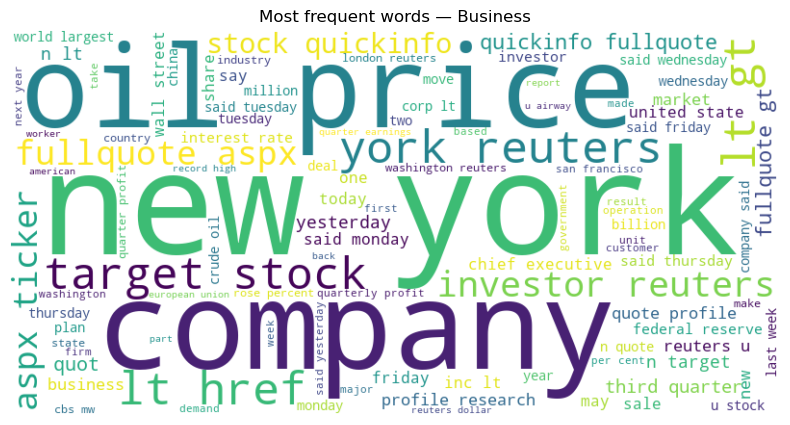

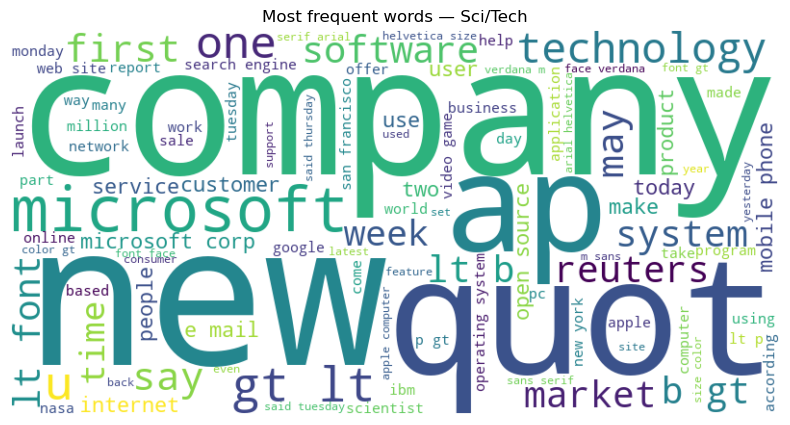

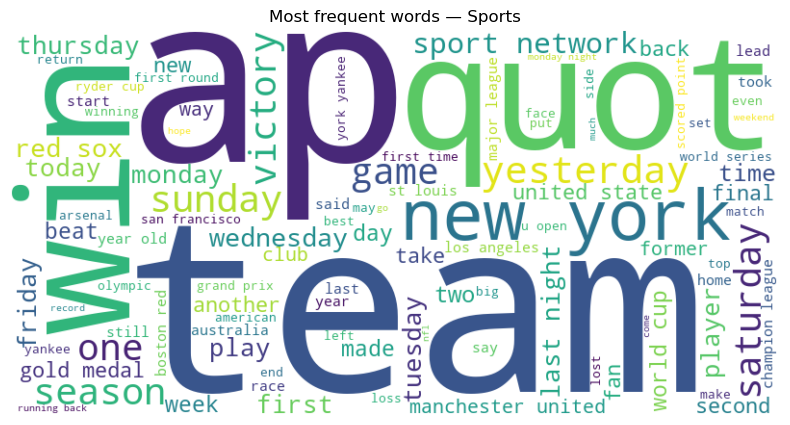

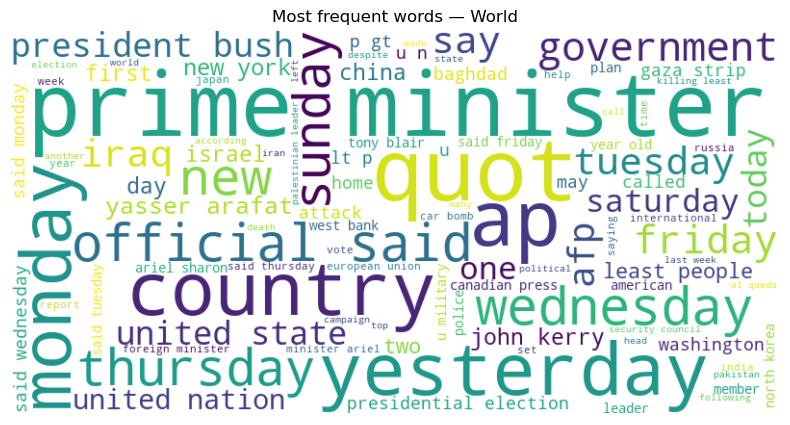

In [52]:
os.makedirs("results/wordclouds", exist_ok=True)
for cls in train_df['label'].unique():
    text_all = " ".join(train_df[train_df['label']==cls]['clean_text'].values)
    if len(text_all.strip()) == 0: continue
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text_all)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off'); plt.title(f"Most frequent words — {cls}")
    plt.show()
    wc.to_file(f"results/wordclouds/{cls.replace('/','_')}_wordcloud.png")


### Save Artifacts & Summary Table

In [53]:
results_df['test_accuracy'] = None
results_df['test_f1'] = None
results_df.loc[results_df['model']==best_model_name,'test_accuracy'] = acc_t
results_df.loc[results_df['model']==best_model_name,'test_f1'] = f1_t
results_df

joblib.dump(best_model, os.path.join(MODEL_DIR, "best_model.joblib"))


['models\\best_model.joblib']

---